In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns; 
import warnings;
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.shape

(918, 12)

In [7]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

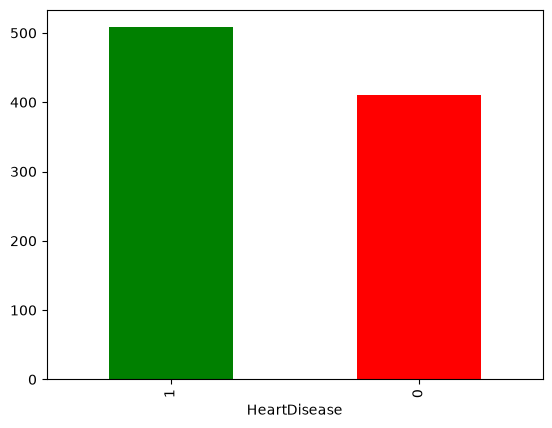

In [11]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['green', 'red'])

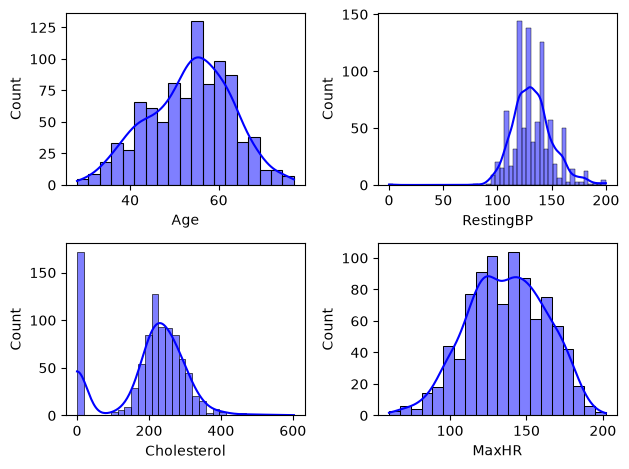

In [14]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True, color='blue')

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()

In [15]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [18]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [20]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(0)

In [21]:
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
resting_bp_mean

np.float64(132.54089422028352)

In [23]:
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(0)

In [26]:
df['Cholesterol'].value_counts()

Cholesterol
245.0    178
254.0     11
223.0     10
220.0     10
211.0      9
        ... 
353.0      1
278.0      1
157.0      1
176.0      1
131.0      1
Name: count, Length: 221, dtype: int64

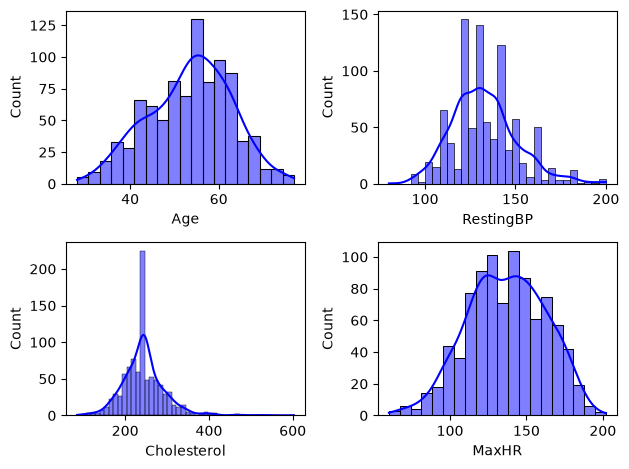

In [27]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True, color='blue')

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

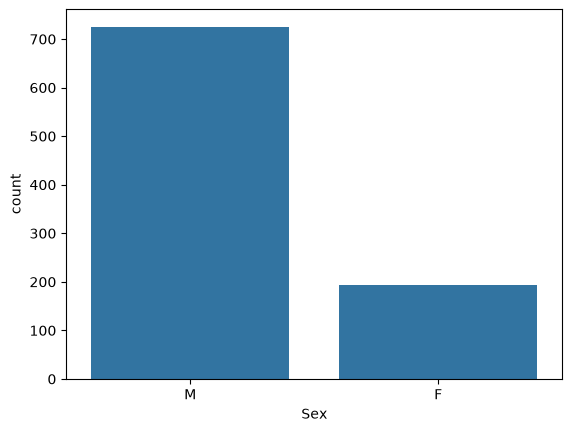

In [30]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

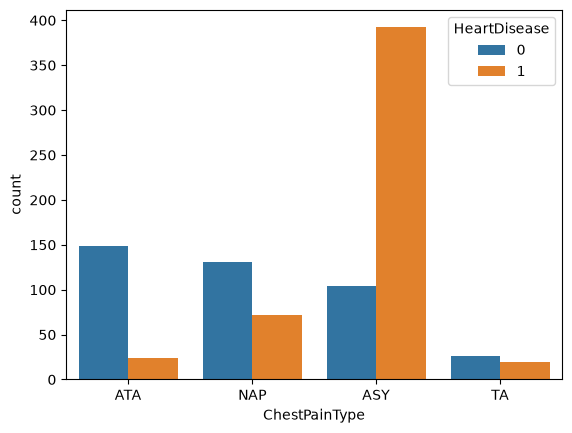

In [33]:
# this means people with heart disease have more chest pain type 3 and people without heart disease have more chest pain type 1
sns.countplot(x = df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='count'>

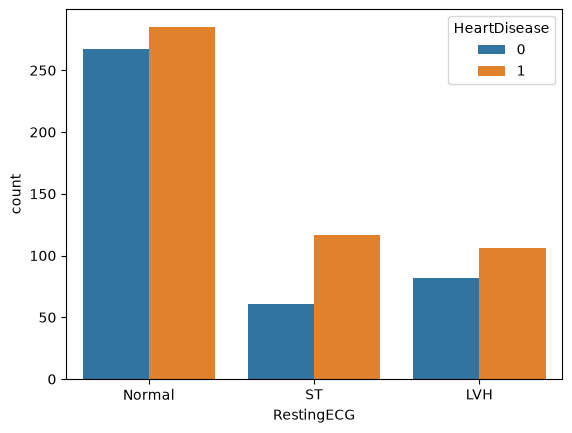

In [35]:
sns.countplot(x = df['RestingECG'], hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

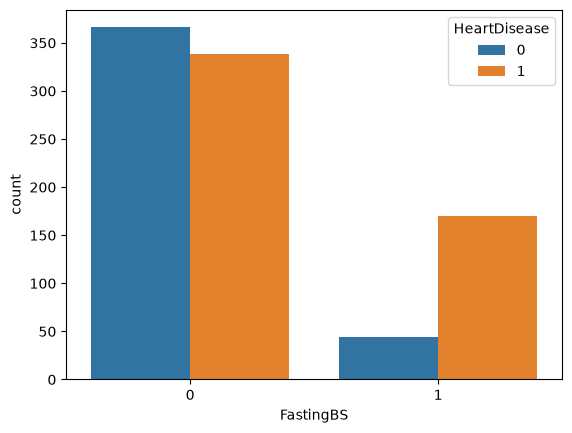

In [37]:
sns.countplot(x = df['FastingBS'], hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

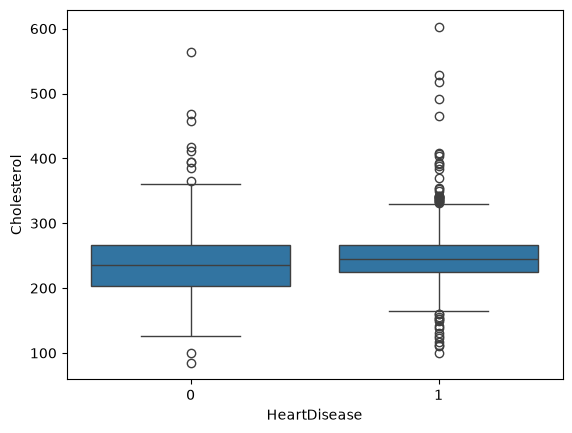

In [39]:
sns.boxplot(y = df['Cholesterol'], x = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

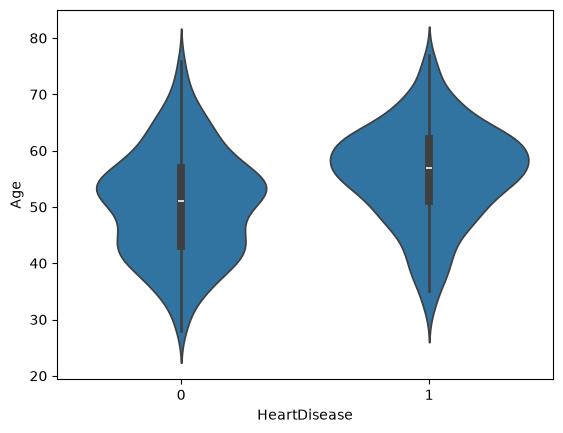

In [40]:
sns.violinplot(x = df['HeartDisease'], y = df['Age'])

<Axes: >

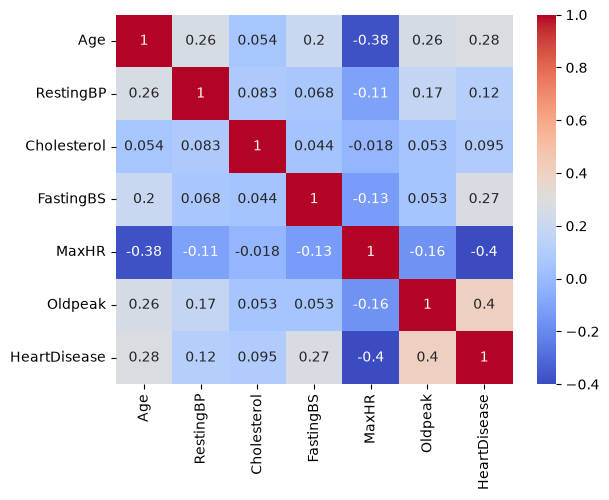

In [42]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [43]:
# Data Preprocessing and Cleaning

df_encode = pd.get_dummies(df)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [47]:
df_encode = df_encode.astype('int')

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encode[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']] = scaler.fit_transform(df_encode[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']])

In [49]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.398662,-0.039684,-0.069751,0,1.535481,-0.383983,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,0.045626,1.417516,-1.432128,0,0.016546,-0.383983,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.398662,-0.039684,-0.069751,0,-1.502389,-0.383983,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,0.045626,-0.039684,-0.069751,0,-1.502389,-0.383983,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.045626,-0.039684,-0.069751,0,0.016546,-0.383983,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [51]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [52]:
from scipy.stats import chi2_contingency

alpha = 0.05

cat_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up']
chi2_results = {}

for col in cat_features:
    contigency = pd.crosstab(df_encode[col], df_encode['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contigency)
    decision = 'Reject Null (Keep the feature)' if p_val < alpha else 'Fail to Reject Null (Drop the feature)'
    chi2_results[col] = {
        'chi2_stat': chi2_stat,
        'p_value': p_val,
        'decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_stat,p_value,decision
HeartDisease,913.958347,0.0,Reject Null (Keep the feature)
ST_Slope_Up,352.823905,0.0,Reject Null (Keep the feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep the feature)
ChestPainType_ASY,243.021138,0.0,Reject Null (Keep the feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep the feature)
ExerciseAngina_N,222.259383,0.0,Reject Null (Keep the feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep the feature)
MaxHR,106.790884,0.0,Reject Null (Keep the feature)
Sex_M,84.145101,0.0,Reject Null (Keep the feature)
Sex_F,84.145101,0.0,Reject Null (Keep the feature)
